# Social Media Donation Conversion Classifier

This notebook builds a **strategy-focused social media pipeline** for the INTEX IS 455 requirement. The goal is to help staff make better decisions **before publishing a post** by predicting whether a planned post is likely to become a **high donation-referral post**.

This notebook is intentionally structured to match the required assignment sections:

1. Problem Framing  
2. Data Acquisition, Preparation & Exploration  
3. Modeling & Feature Selection  
4. Evaluation & Interpretation  
5. Causal and Relationship Analysis  
6. Deployment Notes

The implementation follows the textbook emphasis on:
- prediction vs. explanation
- reproducible data preparation pipelines
- dummy coding / one-hot encoding where appropriate
- thoughtful feature selection
- proper validation
- deployment as part of the pipeline, not an afterthought

## 1. Problem Framing

### Business question
Which planned social media posts are most likely to become **high donation-referral posts**?

### Who cares about this?
This pipeline is most useful for:
- communications and outreach staff planning content
- fundraising staff who want social media to support donation growth
- leadership who want evidence about which content strategy appears to work best

### Why this matters
The case says social media is the organization’s primary channel for reaching potential donors, but the founders are unsure what to post, on which platforms, how often, and at what times. A strategy-focused classifier can help move them from ad hoc posting to a more deliberate content plan.

### Predictive vs. explanatory choice
This notebook is **primarily predictive** because the organization needs a usable pre-publication recommendation tool. The notebook also includes a relationship analysis section so the team can interpret which planning choices seem associated with stronger donation-referral performance.

### Target used in this notebook
This notebook defines:
- `high_donation_referral = 1` if a post lands in the top quartile of donation referrals
- `high_donation_referral = 0` otherwise

### Important design choice
This is a **before publishing** strategy model. The model uses only features known before a post goes live, such as platform, post type, posting hour, day of week, caption length, hashtag count, CTA type, boost status, budget, campaign, and media format. It does **not** use post-publication outcomes like reach, clicks, impressions, or engagement rate.

In [1]:
from pathlib import Path  # File and directory handling
import warnings  # Warning suppression for cleaner notebook output

import numpy as np  # Numerical operations
import pandas as pd  # Tabular data work
import matplotlib.pyplot as plt  # Plotting

try:
    from sklearn.compose import ColumnTransformer  # Apply different preprocessing by column type
    from sklearn.pipeline import Pipeline  # Chain preprocessing and modeling steps
    from sklearn.impute import SimpleImputer  # Fill missing values
    from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Dummy coding and scaling
    from sklearn.feature_selection import SelectFromModel  # Embedded feature selection
    from sklearn.linear_model import LogisticRegression  # Logistic regression classifier
    from sklearn.ensemble import RandomForestClassifier  # Random forest classifier
    from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, RandomizedSearchCV  # Split, validate, and tune models
    from sklearn.metrics import (  # Core evaluation metrics and displays
        roc_auc_score,
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
        confusion_matrix,
        classification_report,
        RocCurveDisplay,
        PrecisionRecallDisplay,
    )
    from sklearn.inspection import permutation_importance  # Model-agnostic feature importance
except ImportError as exc:
    raise ImportError(
        "Missing required Python packages. Install them with: python -m pip install scikit-learn pandas matplotlib"
    ) from exc

warnings.filterwarnings("ignore")  # Suppress non-critical warnings for readability

def resolve_data_dir(candidates):
    for candidate in candidates:  # Check each candidate folder first
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate

    for candidate in candidates:  # If needed, search one level deeper for nested CSV folders
        if candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.csv")):
                    return sub
    raise FileNotFoundError(
        "Could not find a data folder containing CSV files. Checked: "
        + ", ".join(str(p.resolve()) for p in candidates)
    )

SEED = 27  # Reproducibility seed for splits and models
ANALYSIS_CUTOFF = pd.Timestamp("2026-04-06")  # Ignore rows after this date

LOCAL_OUTPUT_DIR = Path("../generated_outputs")  # Local fallback folder for generated notebook outputs
OUTPUT_DIR = Path(os.environ.get("AZUREML_OUTPUT_DIR", str(LOCAL_OUTPUT_DIR)))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR_CANDIDATES = [  # Possible locations for the CSV folder
    Path("../data"),
    Path("./data"),
    Path("/mnt/batch/tasks/shared/LS_root/mounts/clusters/notebookdev/code/data"),
    Path("/lighthouse/lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("/lighthouse/lighthouse_csv_v7"),
    Path("/lighthouse"),
    Path("./lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("./lighthouse_csv_v7"),
    Path("../lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("../lighthouse_csv_v7"),
]

def resolve_data_dir(candidates):
    for candidate in candidates:  # Look for CSV files directly inside each candidate
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate
    for candidate in candidates:  # Then look inside immediate subfolders
        if candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.csv")):
                    return sub
    raise FileNotFoundError(
        "Could not find a data folder containing CSV files. Checked: "
        + ", ".join(str(p.resolve()) for p in candidates)
    )

DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)  # Final resolved data folder

REQUIRED_FILES = {  # Minimum files needed for this notebook
    "social_media_posts": DATA_DIR / "social_media_posts.csv",
    "donations": DATA_DIR / "donations.csv",
}

print("Working directory:", Path.cwd())  # Confirm notebook working directory
print("Resolved data directory:", DATA_DIR.resolve())  # Show the folder being used
print("Output directory:", OUTPUT_DIR.resolve())  # Show where outputs will be saved
print("CSV files found:")
for p in sorted(DATA_DIR.glob("*.csv")):
    print("-", p.name)  # List available CSV files


Working directory: c:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines
Resolved data directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\lighthouse_csv_v7\lighthouse_csv_v7
Output directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs
CSV files found:
- donation_allocations.csv
- donations.csv
- education_records.csv
- health_wellbeing_records.csv
- home_visitations.csv
- in_kind_donation_items.csv
- incident_reports.csv
- intervention_plans.csv
- partner_assignments.csv
- partners.csv
- process_recordings.csv
- public_impact_snapshots.csv
- residents.csv
- safehouse_monthly_metrics.csv
- safehouses.csv
- social_media_posts.csv
- supporters.csv


## 2. Data Acquisition, Preparation & Exploration

This section loads the social media data and prepares a reproducible modeling dataset.

### Tables used
- `social_media_posts`
- `donations` (used only to validate attribution logic, not as a feature source for the pre-publication model)

### Why these tables?
The social media table contains the planning and publishing variables needed for a strategy model. The donations table provides a useful attribution check because some donations reference posts through `referral_post_id`.

In [2]:
def assert_required_files_exist(required_files):
    missing = [name for name, path in required_files.items() if not path.exists()]  # Collect any missing required files
    if missing:
        raise FileNotFoundError(
            f"Missing required CSV files: {missing}. Expected them under: {DATA_DIR.resolve()}"
        )

def load_csv_safe(path, parse_dates=None):
    if not Path(path).exists():  # Stop early if the file path is invalid
        raise FileNotFoundError(f"Could not find file: {path}")
    try:
        df = pd.read_csv(path)  # Load the CSV into a DataFrame
        if parse_dates:
            for col in parse_dates:  # Convert listed date columns when they exist
                if col in df.columns:
                    df[col] = pd.to_datetime(df[col], errors="coerce")
        return df
    except Exception as exc:
        raise RuntimeError(f"Failed to load CSV at {path}: {exc}") from exc

def validate_required_columns(df, table_name, required_columns):
    missing = [col for col in required_columns if col not in df.columns]  # Check for required schema fields
    if missing:
        raise ValueError(f"Table '{table_name}' is missing required columns: {missing}")

assert_required_files_exist(REQUIRED_FILES)  # Verify the needed source files are present

print(load_csv_safe)  # Display helper function reference
print(validate_required_columns)  # Display helper function reference
print(REQUIRED_FILES)  # Display the required file mapping


<function load_csv_safe at 0x0000027EE2099D00>
<function validate_required_columns at 0x0000027EE2099DA0>
{'social_media_posts': WindowsPath('lighthouse_csv_v7/lighthouse_csv_v7/social_media_posts.csv'), 'donations': WindowsPath('lighthouse_csv_v7/lighthouse_csv_v7/donations.csv')}


In [3]:
social_media_posts = load_csv_safe(
    REQUIRED_FILES["social_media_posts"],  # Social media source file
    parse_dates=["created_at"],  # Parse post timestamp
)

donations = load_csv_safe(
    REQUIRED_FILES["donations"],  # Donations source file
    parse_dates=["donation_date"],  # Parse donation timestamp
)

validate_required_columns(
    social_media_posts,
    "social_media_posts",
    [
        "post_id", "created_at", "platform", "post_type", "post_hour",  # Core post identifiers and timing fields
        "day_of_week", "caption_length", "num_hashtags", "call_to_action_type",  # Content feature fields
        "boost_budget_php", "donation_referrals",  # Promotion and outcome fields
    ],
)

validate_required_columns(
    donations,
    "donations",
    ["donation_id", "donation_date", "referral_post_id", "estimated_value"],  # Donation attribution fields
)

print("social_media_posts:", social_media_posts.shape)  # Show loaded post table size
print("donations:", donations.shape)  # Show loaded donation table size


social_media_posts: (812, 39)
donations: (420, 13)


In [4]:
social_media_posts = social_media_posts[social_media_posts["created_at"] <= ANALYSIS_CUTOFF].copy()  # Remove posts after the cutoff date
donations = donations[donations["donation_date"] <= ANALYSIS_CUTOFF].copy()  # Remove donations after the cutoff date

print("Rows after cutoff filtering")
print("social_media_posts:", social_media_posts.shape)  # Filtered post table size
print("donations:", donations.shape)  # Filtered donation table size


Rows after cutoff filtering
social_media_posts: (812, 39)
donations: (420, 13)


In [5]:
attributed_donations = donations[donations["referral_post_id"].notna()].copy()  # Keep only donations tied to a post
attributed_donations["referral_post_id"] = pd.to_numeric(attributed_donations["referral_post_id"], errors="coerce")  # Standardize referral IDs to numeric values

attribution_summary = (
    attributed_donations.groupby("referral_post_id", dropna=True)  # Summarize donations by referred post
    .agg(
        referred_donation_count=("donation_id", "count"),  # Count attributed donations
        referred_estimated_value=("estimated_value", "sum"),  # Sum estimated donation value
    )
    .reset_index()
    .rename(columns={"referral_post_id": "post_id"})  # Align merge key with the posts table
)

social = social_media_posts.merge(attribution_summary, on="post_id", how="left")  # Add donation attribution back to each post
social["referred_donation_count"] = social["referred_donation_count"].fillna(0)  # Replace missing counts with zero
social["referred_estimated_value"] = social["referred_estimated_value"].fillna(0)  # Replace missing values with zero

social[["post_id", "donation_referrals", "referred_donation_count", "referred_estimated_value"]].head()  # Quick attribution comparison


,post_id,donation_referrals,referred_donation_count,referred_estimated_value
0,318,10,0.0,0.0
1,529,2,0.0,0.0
2,86,0,0.0,0.0
3,380,0,0.0,0.0
4,425,2,0.0,0.0


Posts: 812
Platforms: 7
Post types: 6
Average donation referrals per post: 12.8
Median donation referrals per post: 2.0


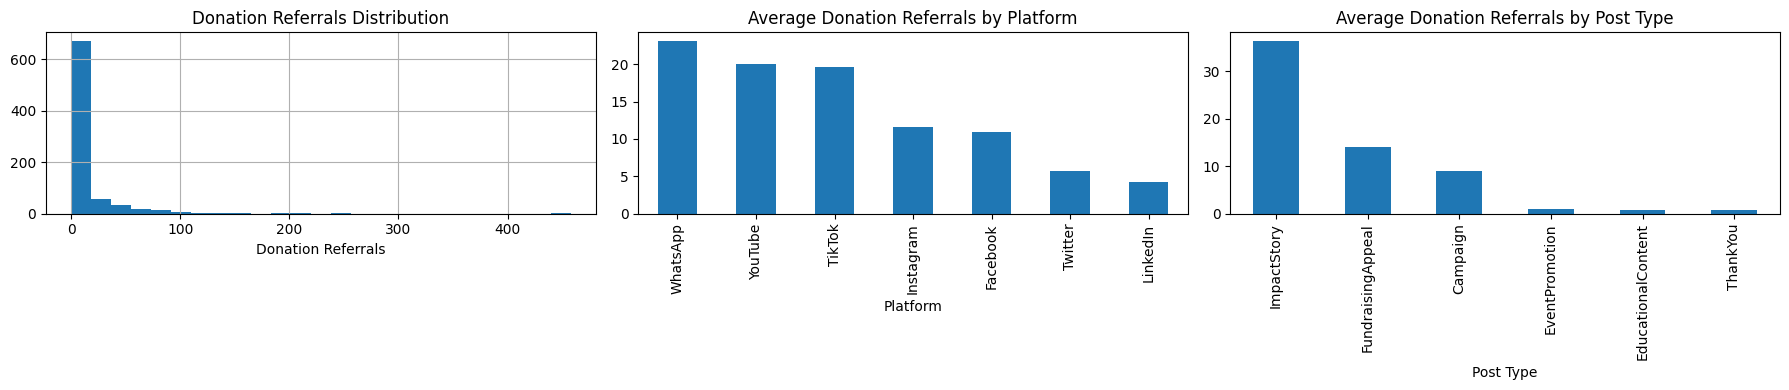

,post_hour,donation_referrals
0,0,0.944444
1,1,1.592593
2,2,0.066667
3,3,1.100000
4,4,0.483871


In [6]:
print("Posts:", len(social))  # Total number of posts after joins and filtering
print("Platforms:", social["platform"].nunique())  # Distinct platforms represented
print("Post types:", social["post_type"].nunique())  # Distinct post types represented
print("Average donation referrals per post:", round(social["donation_referrals"].mean(), 2))  # Mean referrals
print("Median donation referrals per post:", round(social["donation_referrals"].median(), 2))  # Median referrals

fig, axes = plt.subplots(1, 3, figsize=(18, 4))  # Create a three-panel summary figure

social["donation_referrals"].hist(ax=axes[0], bins=25)  # Distribution of referral outcomes
axes[0].set_title("Donation Referrals Distribution")
axes[0].set_xlabel("Donation Referrals")

social.groupby("platform")["donation_referrals"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1])  # Mean referrals by platform
axes[1].set_title("Average Donation Referrals by Platform")
axes[1].set_xlabel("Platform")

social.groupby("post_type")["donation_referrals"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[2])  # Mean referrals by post type
axes[2].set_title("Average Donation Referrals by Post Type")
axes[2].set_xlabel("Post Type")

plt.tight_layout()  # Reduce overlap between plots
plt.show()  # Render the figure

hourly_summary = social.groupby("post_hour")["donation_referrals"].mean().reset_index()  # Average referrals by posting hour
hourly_summary.head()  # Preview hourly performance


In [7]:
positive_threshold = social["donation_referrals"].quantile(0.75)  # Define a high-performing post as top-quartile referrals
social["high_donation_referral"] = (social["donation_referrals"] >= positive_threshold).astype(int)  # Convert the target into a binary label

print("Positive class threshold (top quartile cutoff):", round(float(positive_threshold), 2))  # Show the numeric cutoff
print("Positive class rate:", round(social["high_donation_referral"].mean(), 3))  # Show the share of positive cases

social["high_donation_referral"].value_counts()  # Inspect class balance


Positive class threshold (top quartile cutoff): 11.0
Positive class rate: 0.255


high_donation_referral
0    605
1    207
Name: count, dtype: int64

### Feature engineering choices

This is a strategy pipeline, so the feature set is intentionally limited to variables known before the post is published.

Included feature types:
- platform and post type
- posting time fields
- caption and hashtag structure
- CTA planning fields
- boost planning fields
- campaign information where available

Excluded from modeling:
- post-publication performance metrics such as clicks, impressions, reach, engagement rate, video views, watch time, and subscriber counts at post
- direct outcome fields like `donation_referrals` and referred donation summaries

In [8]:
candidate_columns = [  # Keep only features known before the post outcome occurs
    "platform",
    "post_type",
    "post_hour",
    "day_of_week",
    "caption_length",
    "num_hashtags",
    "mentions_count",
    "call_to_action_type",
    "campaign_name",
    "media_type",
    "is_boosted",
    "boost_budget_php",
]

available_candidate_columns = [c for c in candidate_columns if c in social.columns]  # Keep only columns actually present in the dataset
model_df = social[available_candidate_columns + ["high_donation_referral"]].copy()  # Build the final modeling frame

print("Columns included in the model:")
print(model_df.columns.tolist())  # Review modeling columns
print()
print("Model dataset shape:", model_df.shape)  # Confirm the modeling frame dimensions

missing_fraction = model_df.isna().mean().sort_values(ascending=False)  # Check missingness by column
missing_fraction


Columns included in the model:
['platform', 'post_type', 'post_hour', 'day_of_week', 'caption_length', 'num_hashtags', 'mentions_count', 'call_to_action_type', 'campaign_name', 'media_type', 'is_boosted', 'boost_budget_php', 'high_donation_referral']

Model dataset shape: (812, 13)


boost_budget_php          0.843596
campaign_name             0.714286
call_to_action_type       0.392857
post_type                 0.000000
platform                  0.000000
caption_length            0.000000
day_of_week               0.000000
post_hour                 0.000000
mentions_count            0.000000
num_hashtags              0.000000
media_type                0.000000
is_boosted                0.000000
high_donation_referral    0.000000
dtype: float64

## 3. Modeling & Feature Selection

This section compares two predictive approaches:

1. Feature-selected logistic regression  
2. Random forest classifier

### Validation strategy
Because this is a post-level strategy model rather than a grouped resident model, a standard stratified train/test split and stratified cross-validation are appropriate.

In [9]:
X = model_df.drop(columns=["high_donation_referral"])  # Feature matrix
y = model_df["high_donation_referral"].astype(int)  # Binary target

categorical_features = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype) == "bool"]  # Columns that need dummy coding
numeric_features = [c for c in X.columns if c not in categorical_features]  # Remaining numeric columns

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,  # Hold out 25 percent for final evaluation
    random_state=SEED,  # Reproducible split
    stratify=y,  # Preserve class balance
)

print("Train shape:", X_train.shape)  # Training feature matrix size
print("Test shape:", X_test.shape)  # Test feature matrix size
print("Train positive rate:", round(y_train.mean(), 3))  # Training class balance
print("Test positive rate:", round(y_test.mean(), 3))  # Test class balance
print("Numeric features:", numeric_features)  # Numeric predictor list
print("Categorical features:", categorical_features)  # Categorical predictor list


Train shape: (609, 12)
Test shape: (203, 12)
Train positive rate: 0.255
Test positive rate: 0.256
Numeric features: ['post_hour', 'caption_length', 'num_hashtags', 'mentions_count', 'boost_budget_php']
Categorical features: ['platform', 'post_type', 'day_of_week', 'call_to_action_type', 'campaign_name', 'media_type', 'is_boosted']


In [10]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # Fill missing numeric values
    ("scaler", StandardScaler()),  # Standardize numeric columns
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Fill missing categorical values
    ("onehot", OneHotEncoder(handle_unknown="ignore")),  # Dummy code categories safely
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),  # Apply numeric preprocessing
        ("cat", categorical_pipe, categorical_features),  # Apply categorical preprocessing
    ]
)

logit_feature_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty="l1",  # L1 penalty shrinks weaker features toward zero
        solver="liblinear",  # Solver compatible with L1 regularization
        class_weight="balanced",  # Adjust for class imbalance
        max_iter=2000,  # Give the model enough iterations to converge
        random_state=SEED,  # Reproducibility
    ),
    threshold="median",  # Keep features at or above the median importance
)

logit_pipeline = Pipeline(steps=[
    ("prep", preprocessor),  # Shared preprocessing
    ("feature_select", logit_feature_selector),  # Embedded feature selection
    ("model", LogisticRegression(
        class_weight="balanced",  # Adjust for class imbalance
        max_iter=2000,  # Allow more optimization steps
        random_state=SEED,  # Reproducibility
    )),
])

rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),  # Shared preprocessing
    ("model", RandomForestClassifier(
        n_estimators=300,  # Number of trees
        min_samples_leaf=2,  # Slight regularization at the leaf level
        class_weight="balanced",  # Adjust for class imbalance
        random_state=SEED,  # Reproducibility
        n_jobs=-1,  # Use all available CPU cores
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)  # Balanced cross-validation folds
scoring = {
    "roc_auc": "roc_auc",  # Ranking quality across thresholds
    "avg_precision": "average_precision",  # Precision-recall summary
    "f1": "f1",  # Harmonic mean of precision and recall
    "precision": "precision",  # Positive prediction quality
    "recall": "recall",  # Positive case capture rate
}

logit_cv = cross_validate(logit_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=None)  # Cross-validate logistic candidate
rf_cv = cross_validate(rf_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=None)  # Cross-validate random forest candidate

cv_results = pd.DataFrame({
    "model": ["LogisticRegression+FeatureSelection", "RandomForest"],
    "cv_roc_auc_mean": [logit_cv["test_roc_auc"].mean(), rf_cv["test_roc_auc"].mean()],  # Mean ROC AUC across folds
    "cv_avg_precision_mean": [logit_cv["test_avg_precision"].mean(), rf_cv["test_avg_precision"].mean()],  # Mean average precision
    "cv_f1_mean": [logit_cv["test_f1"].mean(), rf_cv["test_f1"].mean()],  # Mean F1 score
    "cv_precision_mean": [logit_cv["test_precision"].mean(), rf_cv["test_precision"].mean()],  # Mean precision
    "cv_recall_mean": [logit_cv["test_recall"].mean(), rf_cv["test_recall"].mean()],  # Mean recall
})

cv_results.sort_values("cv_roc_auc_mean", ascending=False)  # Rank candidates by ROC AUC


,model,cv_roc_auc_mean,cv_avg_precision_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
1,RandomForest,0.930650,0.816524,0.746035,0.746499,0.748387
0,LogisticRegression+FeatureSelection,0.923215,0.811860,0.724825,0.635773,0.845161


In [11]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,  # Tune the random forest pipeline
    param_distributions={
        "model__n_estimators": [200, 300, 500],  # Candidate tree counts
        "model__max_depth": [None, 4, 6, 8],  # Candidate maximum depths
        "model__min_samples_leaf": [1, 2, 4, 6],  # Candidate leaf sizes
        "model__max_features": ["sqrt", "log2", None],  # Candidate feature sampling rules
    },
    n_iter=10,  # Number of random parameter combinations to try
    scoring="roc_auc",  # Optimize for ROC AUC
    cv=cv,  # Reuse stratified folds
    random_state=SEED,  # Reproducibility
    n_jobs=-1,  # Parallelize the search
    verbose=0,  # Keep output quiet
)

rf_search.fit(X_train, y_train)  # Run the parameter search

best_rf_pipeline = rf_search.best_estimator_  # Save the best tuned pipeline
print("Best RF params:", rf_search.best_params_)  # Best parameter combination
print("Best RF CV ROC AUC:", round(rf_search.best_score_, 4))  # Best validation score


Best RF params: {'model__n_estimators': 500, 'model__min_samples_leaf': 6, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Best RF CV ROC AUC: 0.9362


## 4. Evaluation & Interpretation

This section evaluates the selected predictive model on a holdout test set.

### Error costs in this context
- False positive: the model predicts a planned post will likely be high-converting, but it is not.
- False negative: the model predicts a planned post will not be high-converting, but it actually would have been.

Because the organization has limited communications capacity, both errors matter, but false negatives may be especially costly if they prevent high-potential fundraising content from being prioritized.

In [12]:
logit_pipeline.fit(X_train, y_train)  # Fit logistic model on the training set
best_rf_pipeline.fit(X_train, y_train)  # Fit tuned random forest on the training set

def evaluate_classifier(model, X_eval, y_eval, model_name):
    y_proba = model.predict_proba(X_eval)[:, 1]  # Positive-class probabilities
    y_pred = (y_proba >= 0.50).astype(int)  # Convert probabilities to class labels with a 0.50 threshold

    metrics = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_eval, y_proba),  # Threshold-independent ranking metric
        "avg_precision": average_precision_score(y_eval, y_proba),  # Precision-recall summary metric
        "f1": f1_score(y_eval, y_pred, zero_division=0),  # Balance of precision and recall
        "precision": precision_score(y_eval, y_pred, zero_division=0),  # Positive prediction accuracy
        "recall": recall_score(y_eval, y_pred, zero_division=0),  # Share of positives found
    }
    return metrics, y_proba, y_pred  # Return metrics plus raw predictions for later use

logit_metrics, logit_proba, logit_pred = evaluate_classifier(logit_pipeline, X_test, y_test, "LogisticRegression+FeatureSelection")  # Evaluate logistic model
rf_metrics, rf_proba, rf_pred = evaluate_classifier(best_rf_pipeline, X_test, y_test, "RandomForestTuned")  # Evaluate random forest model

test_results = pd.DataFrame([logit_metrics, rf_metrics]).sort_values("roc_auc", ascending=False)  # Compare holdout test performance
test_results


,model,roc_auc,avg_precision,f1,precision,recall
1,RandomForestTuned,0.893148,0.725000,0.694915,0.621212,0.788462
0,LogisticRegression+FeatureSelection,0.856024,0.671692,0.656489,0.544304,0.826923


In [13]:
if rf_metrics["roc_auc"] >= logit_metrics["roc_auc"]:  # Select the better holdout ROC AUC model
    final_model = best_rf_pipeline  # Keep tuned random forest
    final_model_name = "RandomForestTuned"
    final_proba = rf_proba  # Reuse saved probabilities
    final_pred = rf_pred  # Reuse saved class predictions
else:
    final_model = logit_pipeline  # Keep logistic pipeline
    final_model_name = "LogisticRegression+FeatureSelection"
    final_proba = logit_proba  # Reuse saved probabilities
    final_pred = logit_pred  # Reuse saved class predictions

print("Selected final predictive model:", final_model_name)  # Report the chosen deployment model
print(classification_report(y_test, final_pred, zero_division=0))  # Detailed holdout classification metrics

cm = confusion_matrix(y_test, final_pred)  # Confusion matrix for the selected model
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])  # Label rows and columns for readability
cm_df


Selected final predictive model: RandomForestTuned
              precision    recall  f1-score   support

           0       0.92      0.83      0.88       151
           1       0.62      0.79      0.69        52

    accuracy                           0.82       203
   macro avg       0.77      0.81      0.78       203
weighted avg       0.84      0.82      0.83       203



,Predicted 0,Predicted 1
Actual 0,126,25
Actual 1,11,41


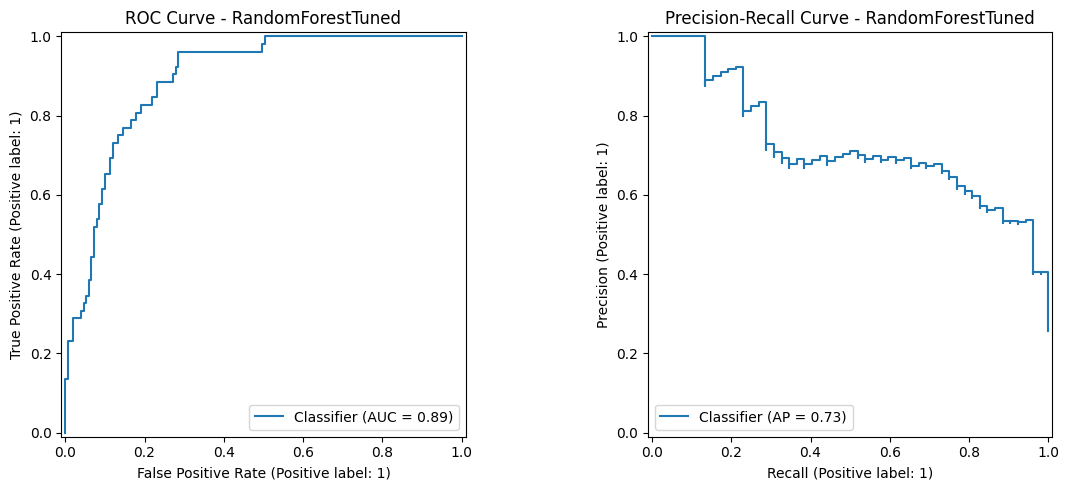

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Create ROC and precision-recall panels
RocCurveDisplay.from_predictions(y_test, final_proba, ax=axes[0])  # Plot ROC curve
axes[0].set_title(f"ROC Curve - {final_model_name}")
PrecisionRecallDisplay.from_predictions(y_test, final_proba, ax=axes[1])  # Plot precision-recall curve
axes[1].set_title(f"Precision-Recall Curve - {final_model_name}")
plt.tight_layout()  # Prevent plot overlap
plt.show()  # Render the evaluation plots


### Business interpretation

If this model performs reasonably well, the organization can use it as a pre-publication planning tool, not as a fully automatic posting system.

Useful operational interpretations:
- planned posts with the highest probabilities should be prioritized for the content calendar
- staff can compare platform/post-type/CTA combinations before publishing
- leadership can use the outputs to shift social strategy toward higher-conversion content patterns

## 5. Causal and Relationship Analysis

This section is deliberately separate from pure predictive evaluation.

The goal here is to answer:
- which planning features matter most?
- do the discovered relationships make theoretical sense?
- what does the model reveal about post strategy?
- which conclusions are associational versus potentially causal?

This notebook does **not** claim that the model proves causation. The data is observational and synthetic. That means the relationships can guide strategy without automatically proving that a specific post design choice causes donation referrals.

In [15]:
perm = permutation_importance(
    final_model,  # Use the selected final model
    X_test,  # Evaluate importance on unseen test data
    y_test,  # True test labels
    n_repeats=15,  # Repeat shuffling for stability
    random_state=SEED,  # Reproducibility
    scoring="roc_auc",  # Measure importance by ROC AUC drop
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,  # Original feature names
    "importance_mean": perm.importances_mean,  # Average importance across repeats
    "importance_std": perm.importances_std,  # Importance variability across repeats
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)  # Show the top features


,feature,importance_mean,importance_std
1,post_type,3.174648e-01,0.036132
2,post_hour,6.168280e-02,0.016740
4,caption_length,7.581932e-03,0.005599
0,platform,6.248939e-03,0.004898
10,is_boosted,5.781966e-03,0.003474
7,call_to_action_type,2.827305e-03,0.001770
9,media_type,2.793344e-03,0.004220
11,boost_budget_php,1.231109e-03,0.001407
8,campaign_name,7.216845e-04,0.000523
5,num_hashtags,6.661338e-17,0.000875


In [16]:
explanatory_features = [c for c in X.columns if c in [  # Narrower feature set for a more interpretable model
    "platform",
    "post_type",
    "post_hour",
    "day_of_week",
    "caption_length",
    "num_hashtags",
    "call_to_action_type",
    "campaign_name",
    "media_type",
    "is_boosted",
    "boost_budget_php",
]]

X_explain = X_train[explanatory_features].copy()  # Explanatory training feature set
cat_explain = [c for c in explanatory_features if X_explain[c].dtype == "object" or str(X_explain[c].dtype) == "bool"]  # Explanatory categorical features
num_explain = [c for c in explanatory_features if c not in cat_explain]  # Explanatory numeric features

explain_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_explain),  # Numeric preprocessing
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_explain),  # Categorical preprocessing
    ]
)

explain_model = Pipeline(steps=[
    ("prep", explain_preprocessor),  # Shared explanatory preprocessing
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),  # Interpretable linear classifier
])

explain_model.fit(X_explain, y_train)  # Fit the explanatory model on the training set

feature_names = explain_model.named_steps["prep"].get_feature_names_out()  # Expanded feature names after dummy coding
coef_values = explain_model.named_steps["model"].coef_[0]  # Logistic coefficients for the positive class

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef_values,  # Signed coefficient value
    "abs_coefficient": np.abs(coef_values),  # Absolute magnitude for ranking
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)  # Show the strongest explanatory signals


,feature,coefficient,abs_coefficient
15,cat__post_type_ImpactStory,3.459405,3.459405
16,cat__post_type_ThankYou,-2.447897,2.447897
12,cat__post_type_EducationalContent,-1.930498,1.930498
14,cat__post_type_FundraisingAppeal,1.873520,1.873520
13,cat__post_type_EventPromotion,-1.696680,1.696680
6,cat__platform_LinkedIn,-1.220103,1.220103
10,cat__platform_YouTube,1.103727,1.103727
0,num__post_hour,0.965547,0.965547
35,cat__media_type_Text,-0.902528,0.902528
11,cat__post_type_Campaign,0.735996,0.735996


### Relationship analysis write-up

When you review the feature importance and coefficient outputs above, look for patterns such as:
- whether certain platforms appear more associated with high-conversion posts
- whether specific post types seem more fundraising-effective
- whether certain posting hours appear more favorable
- whether boosted content, CTA choices, or caption structure are associated with stronger outcomes

Important caution:
- these relationships are not automatically causal
- boosted posts may correlate with stronger results because the team already chooses to boost higher-priority content
- campaign_name may correlate with conversion because campaigns differ in urgency or donor intent
- platform effects may partly reflect audience differences rather than the platform itself being the sole cause

## 6. Deployment Notes

Following the textbook deployment pattern, the web application should read predictions, not retrain the model during page load.

### Proposed integration
This pipeline fits naturally into a **Reports & Analytics** page or a staff-facing **Social Media Strategy** component.

### Suggested UI behavior
The app can display:
- planned platform
- planned post type
- planned posting hour
- predicted high-conversion probability
- predicted high / not high conversion flag
- simple strategy guidance such as “strong candidate” or “lower expected conversion”

### Recommended backend contract
The ML pipeline can write a scoring table or CSV with fields like:
- `scenario_id`
- `platform`
- `post_type`
- `post_hour`
- `predicted_high_conversion_probability`
- `predicted_high_conversion_flag`
- `model_version`
- `prediction_timestamp`

In [17]:
def mode_or_default(series, default_value):
    series = series.dropna()  # Ignore missing values before taking the mode
    if series.empty:
        return default_value  # Fall back when the series has no non-missing values
    return series.mode().iloc[0]  # Return the most common observed value

platform_options = sorted([x for x in social["platform"].dropna().unique().tolist()])  # Available platform scenarios
post_type_options = sorted([x for x in social["post_type"].dropna().unique().tolist()])  # Available post type scenarios

common_day = mode_or_default(social["day_of_week"], "Monday")  # Most common day of week
common_cta = mode_or_default(social["call_to_action_type"], "Donate")  # Most common call to action
common_campaign = mode_or_default(social["campaign_name"], "General")  # Most common campaign
common_media = mode_or_default(social["media_type"], "Image")  # Most common media type

scenario_rows = []  # Store candidate posting scenarios
scenario_id = 1  # Sequential scenario identifier

for platform in platform_options:
    for post_type in post_type_options[:6]:  # Limit to the first six post types for a compact scenario table
        for hour in [8, 10, 13, 18, 19]:  # Candidate posting hours
            scenario_rows.append({
                "scenario_id": scenario_id,
                "platform": platform,
                "post_type": post_type,
                "post_hour": hour,
                "day_of_week": common_day,
                "caption_length": int(social["caption_length"].median()) if "caption_length" in social.columns else 140,  # Typical caption length
                "num_hashtags": int(social["num_hashtags"].median()) if "num_hashtags" in social.columns else 2,  # Typical hashtag count
                "mentions_count": int(social["mentions_count"].median()) if "mentions_count" in social.columns else 0,  # Typical mention count
                "call_to_action_type": common_cta,
                "campaign_name": common_campaign,
                "media_type": common_media,
                "is_boosted": False if "is_boosted" in social.columns else np.nan,  # Default unpaid scenario
                "boost_budget_php": 0 if "boost_budget_php" in social.columns else np.nan,  # Zero boost budget by default
            })
            scenario_id += 1

planning_scenarios = pd.DataFrame(scenario_rows)  # Convert scenarios to a DataFrame
model_columns = X.columns.tolist()  # Match training feature order
planning_scenarios = planning_scenarios[model_columns]  # Keep only model-ready columns in the expected order

planning_scenarios["predicted_high_conversion_probability"] = final_model.predict_proba(planning_scenarios)[:, 1]  # Score each scenario
planning_scenarios["predicted_high_conversion_flag"] = (planning_scenarios["predicted_high_conversion_probability"] >= 0.50).astype(int)  # Convert scores to class labels
planning_scenarios["prediction_timestamp"] = pd.Timestamp.now()  # Stamp when the scores were generated
planning_scenarios["model_name"] = final_model_name  # Record the scoring model

planning_output = planning_scenarios.sort_values("predicted_high_conversion_probability", ascending=False).copy()  # Rank the best scenarios first
output_path = OUTPUT_DIR / "donor_lapse_scores.csv"  # Output file path
planning_output.to_csv(output_path, index=False)  # Save ranked scenarios to CSV

print(f"Saved planning output to: {output_path.resolve()}")  # Confirm save location
planning_output.head(20)  # Preview the top scored scenarios


Saved planning output to: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs\social_media_planning_scores.csv


,platform,post_type,post_hour,day_of_week,caption_length,num_hashtags,mentions_count,call_to_action_type,campaign_name,media_type,is_boosted,boost_budget_php,predicted_high_conversion_probability,predicted_high_conversion_flag,prediction_timestamp,model_name
174,WhatsApp,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.862317,1,2026-04-08 16:39:15.950332,RandomForestTuned
173,WhatsApp,ImpactStory,18,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.861457,1,2026-04-08 16:39:15.950332,RandomForestTuned
171,WhatsApp,ImpactStory,10,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.855289,1,2026-04-08 16:39:15.950332,RandomForestTuned
172,WhatsApp,ImpactStory,13,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.850654,1,2026-04-08 16:39:15.950332,RandomForestTuned
204,YouTube,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.846107,1,2026-04-08 16:39:15.950332,RandomForestTuned
203,YouTube,ImpactStory,18,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.845656,1,2026-04-08 16:39:15.950332,RandomForestTuned
201,YouTube,ImpactStory,10,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.844515,1,2026-04-08 16:39:15.950332,RandomForestTuned
54,Instagram,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.841168,1,2026-04-08 16:39:15.950332,RandomForestTuned
53,Instagram,ImpactStory,18,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.840287,1,2026-04-08 16:39:15.950332,RandomForestTuned
114,TikTok,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.839492,1,2026-04-08 16:39:15.950332,RandomForestTuned


## Final Notes

This notebook is designed to be:
- executable top to bottom
- explicit about the prediction vs. explanation distinction
- aligned with the textbook chapters on preparation, classification, evaluation, feature selection, and deployment
- useful for a staff-facing analytics or strategy page in the web application

In [ ]:
# Mirror outputs back to the local repo fallback after writing to Azure ML output storage when available.
import shutil
LOCAL_OUTPUT_DIR = Path("../generated_outputs")
if OUTPUT_DIR.resolve() != LOCAL_OUTPUT_DIR.resolve():
    LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for artifact in OUTPUT_DIR.glob('*'):
        if artifact.is_file():
            shutil.copy2(artifact, LOCAL_OUTPUT_DIR / artifact.name)
    print(f'Mirrored outputs to local fallback: {LOCAL_OUTPUT_DIR.resolve()}')
